In [11]:
# ==========================================
# SUPRERSTORE SALES DATA ANALYSIS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [12]:
from google.colab import files

uploaded = files.upload()

Saving SampleSuperstore.csv to SampleSuperstore (1).csv


### Load Dataset

In [13]:
df = pd.read_csv("SampleSuperstore.csv", encoding="latin1")

print("Dataset loaded successfully!")

Dataset loaded successfully!


### Inspect Dataset Structure

In [14]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Rows: 9994
Columns: 13

Column Names:
['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']


### Understand the Dataset

In [15]:
print("First 5 Rows:")
display(df.head())

First 5 Rows:


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [16]:
print("Last 5 Rows:")
display(df.tail())

Last 5 Rows:


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


In [17]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [18]:
print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Data Quality Check

#### Missing Values

In [19]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [20]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

display(missing_summary)

,Missing Values,Percentage
Ship Mode,0,0.0
Segment,0,0.0
Country,0,0.0
City,0,0.0
State,0,0.0
Postal Code,0,0.0
Region,0,0.0
Category,0,0.0
Sub-Category,0,0.0
Sales,0,0.0


#### Duplicate Records

In [21]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 17
Shape after removing duplicates: (9977, 13)


#### Check Data Types

In [22]:
print("Current Data Types:")
print(df.dtypes)

Current Data Types:
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object


In [23]:
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print("Data Types after converting numeric columns:")
print(df[numeric_columns].dtypes)

Data Types after converting numeric columns:
Sales       float64
Quantity      int64
Discount    float64
Profit      float64
dtype: object


### Basic KPI Analysis

#### Total Sales

In [24]:
total_sales = df["Sales"].sum()

print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,296,195.59


#### Total Profit

In [25]:
total_profit = df["Profit"].sum()

print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,241.42


#### Total Quantity

In [26]:
total_quantity = df["Quantity"].sum()

print(f"Total Quantity Sold: {total_quantity:,}")

Total Quantity Sold: 37,820


#### Number of Transactions

In [27]:
total_transactions = len(df)

print(f"Total Transactions: {total_transactions:,}")

Total Transactions: 9,977


#### Average Sales per Transaction

In [28]:
average_sales = df["Sales"].mean()

print(f"Average Sales per Transaction: ${average_sales:,.2f}")

Average Sales per Transaction: $230.15


#### Profit Margin

In [29]:
profit_margin = (total_profit / total_sales) * 100

print(f"Profit Margin: {profit_margin:.2f}%")

Profit Margin: 12.47%


### Category Analysis

In [30]:
category_analysis = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

display(category_analysis)

,Total_Sales,Total_Profit,Quantity
Category,,,
Technology,836154.0330,145454.9481,6939
Furniture,741306.3133,18421.8137,8020
Office Supplies,718735.2440,122364.6608,22861


#### Category Sales Chart

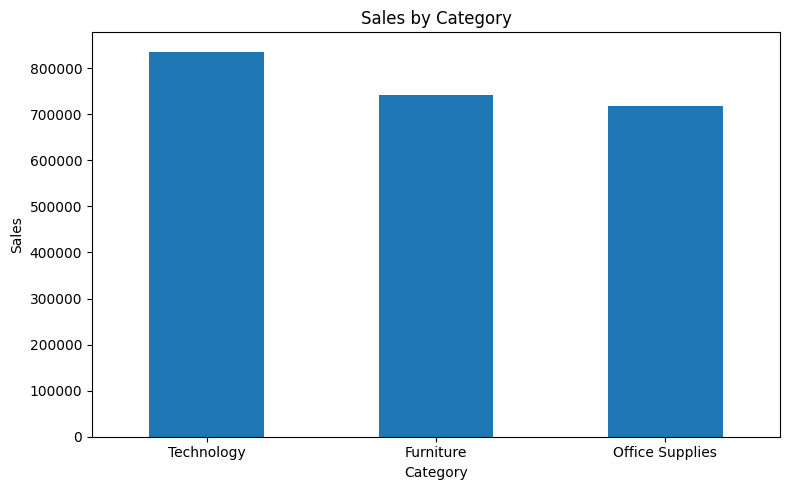

In [31]:
plt.figure(figsize=(8, 5))

category_analysis["Total_Sales"].plot(
    kind="bar"
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Sub-Category Analysis

In [32]:
subcategory_analysis = (
    df.groupby("Sub-Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

display(subcategory_analysis)

,Total_Sales,Total_Profit,Quantity
Sub-Category,,,
Phones,330007.0540,44515.7306,3289
Chairs,327777.7610,26567.1278,2351
Storage,223843.6080,21278.8264,3158
Tables,206965.5320,-17725.4811,1241
Binders,203409.1690,30228.0003,5971
Machines,189238.6310,3384.7569,440
Accessories,167380.3180,41936.6357,2976
Copiers,149528.0300,55617.8249,234
Bookcases,114879.9963,-3472.5560,868


#### Top 10 Sub-Categories

In [33]:
top_subcategories = subcategory_analysis.head(10)

display(top_subcategories)

,Total_Sales,Total_Profit,Quantity
Sub-Category,,,
Phones,330007.0540,44515.7306,3289
Chairs,327777.7610,26567.1278,2351
Storage,223843.6080,21278.8264,3158
Tables,206965.5320,-17725.4811,1241
Binders,203409.1690,30228.0003,5971
Machines,189238.6310,3384.7569,440
Accessories,167380.3180,41936.6357,2976
Copiers,149528.0300,55617.8249,234
Bookcases,114879.9963,-3472.5560,868


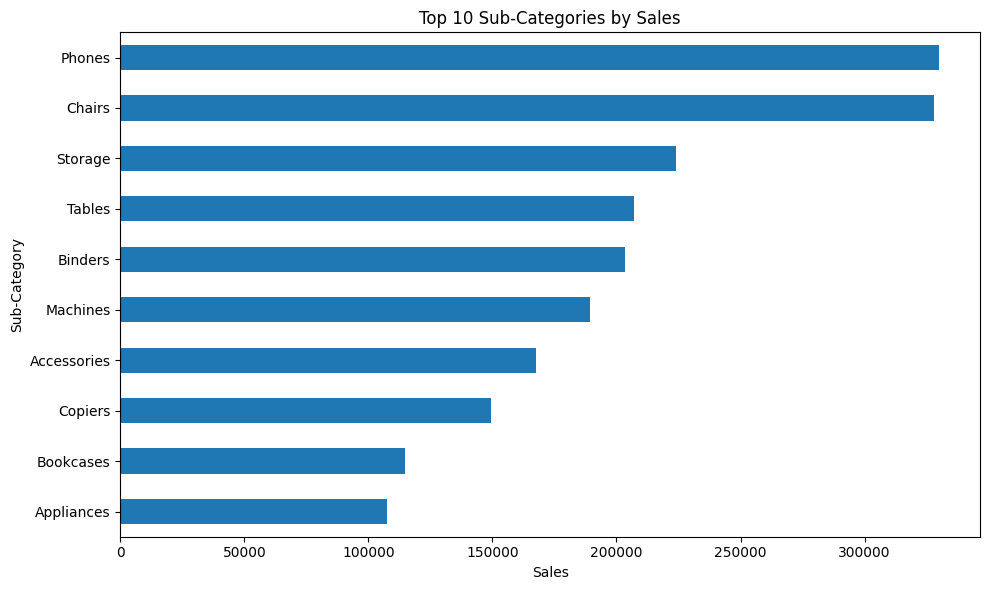

In [34]:
plt.figure(figsize=(10, 6))

top_subcategories["Total_Sales"].sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

### Region Analysis

In [35]:
region_analysis = (
    df.groupby("Region")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

display(region_analysis)

,Total_Sales,Total_Profit,Quantity
Region,,,
West,725255.6365,108329.8079,12234
East,678435.1960,91506.3092,10609
Central,500782.8528,39655.8752,8768
South,391721.9050,46749.4303,6209


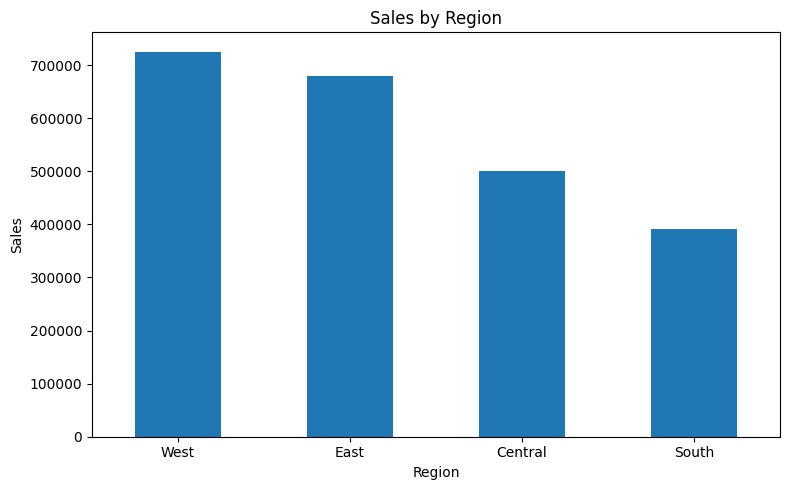

In [36]:
plt.figure(figsize=(8, 5))

region_analysis["Total_Sales"].plot(
    kind="bar"
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### State-Level Analysis

In [37]:
state_analysis = (
    df.groupby("State")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

print("Top 10 States by Sales:")
top_states = state_analysis.head(10)
display(top_states)

print("\nBottom 10 States by Sales:")
bottom_states = state_analysis.tail(10)
display(bottom_states)

Top 10 States by Sales:


,Total_Sales,Total_Profit,Quantity
State,,,
California,457576.2715,76330.7891,7649
New York,310827.1510,74015.4622,4220
Texas,170124.5418,-25750.9833,3718
Washington,138560.8100,33368.2375,1871
Pennsylvania,116496.3620,-15565.4035,2150
Florida,89473.7080,-3399.3017,1379
Illinois,80162.5370,-12601.6500,1842
Ohio,77976.7640,-16959.3178,1757
Michigan,75879.6440,24428.0903,943



Bottom 10 States by Sales:


,Total_Sales,Total_Profit,Quantity
State,,,
New Mexico,4783.522,1157.1161,151
Iowa,4579.760,1183.8119,112
Idaho,4382.486,826.7231,64
Kansas,2914.310,836.4435,74
District of Columbia,2865.020,1059.5893,40
Wyoming,1603.136,100.1960,4
South Dakota,1315.560,394.8283,42
Maine,1270.530,454.4862,35
West Virginia,1209.824,185.9216,18


### Segment Analysis

In [38]:
segment_analysis = (
    df.groupby("Segment")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

display(segment_analysis)

,Total_Sales,Total_Profit,Quantity
Segment,,,
Consumer,1.160833e+06,134007.4413,19497
Corporate,7.060701e+05,91954.9798,11591
Home Office,4.292927e+05,60279.0015,6732


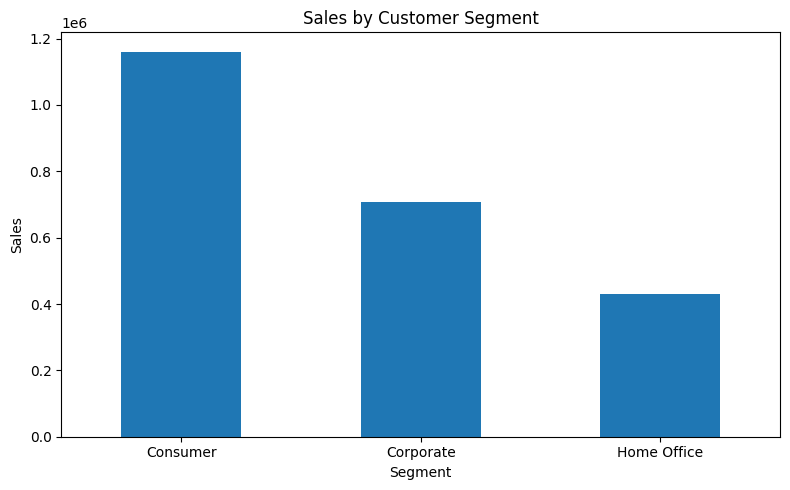

In [39]:
plt.figure(figsize=(8, 5))

segment_analysis["Total_Sales"].plot(
    kind="bar"
)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Discount vs Profit Analysis

In [40]:
discount_analysis = (
    df.groupby("Discount")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .sort_index()
)

display(discount_analysis)

,Total_Sales,Total_Profit,Quantity
Discount,,,
0.00,1.087278e+06,320844.4073,18230
0.10,5.436935e+04,9029.1770,373
0.15,2.755852e+04,1418.9915,198
0.20,7.645049e+05,90306.6070,13649
0.30,1.029453e+05,-10357.2186,847
0.32,1.449346e+04,-2391.1377,105
0.40,1.164178e+05,-23057.0504,786
0.45,5.484974e+03,-2493.1111,45
0.50,5.891854e+04,-20506.4281,241


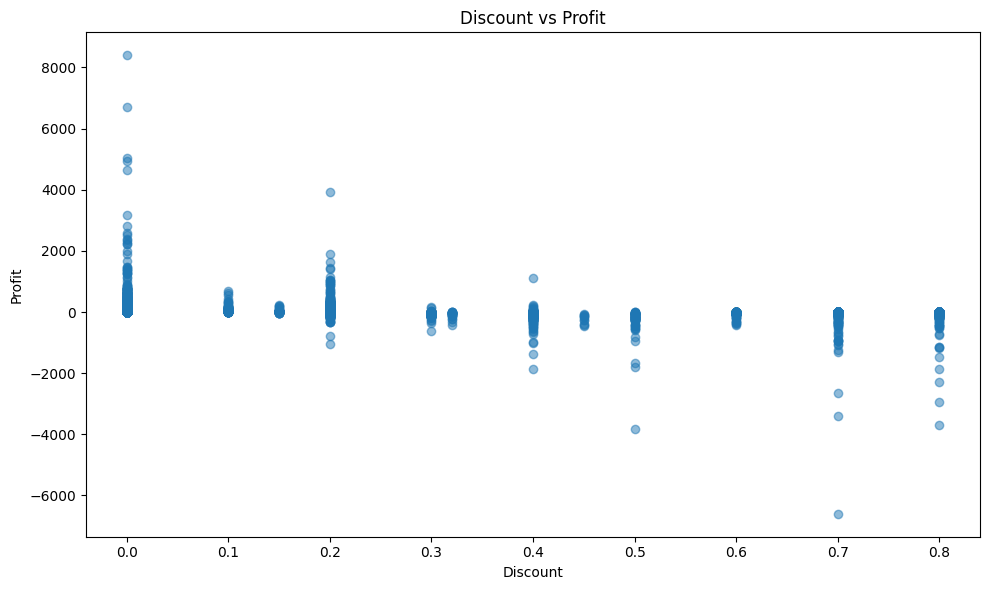

In [41]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

### Find Most/Least Profitable Products

In [42]:
product_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print("Most profitable sub-categories:")
display(product_profit.head(10))

print("\nLeast profitable sub-categories:")
display(product_profit.tail(10))

Most profitable sub-categories:


,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,33944.2395
Binders,30228.0003
Chairs,26567.1278
Storage,21278.8264
Appliances,18138.0054
Furnishings,13052.7230



Least profitable sub-categories:


,Profit
Sub-Category,
Appliances,18138.0054
Furnishings,13052.7230
Envelopes,6964.1767
Art,6524.6118
Labels,5526.3820
Machines,3384.7569
Fasteners,949.5182
Supplies,-1189.0995
Bookcases,-3472.5560


### Create a Summary Table

In [43]:
summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Quantity",
        "Total Transactions",
        "Average Sales",
        "Profit Margin"
    ],

    "Value": [
        total_sales,
        total_profit,
        total_quantity,
        total_transactions,
        average_sales,
        profit_margin
    ]
})

display(summary)

,Metric,Value
0,Total Sales,2.296196e+06
1,Total Profit,2.862414e+05
2,Total Quantity,3.782000e+04
3,Total Transactions,9.977000e+03
4,Average Sales,2.301489e+02
5,Profit Margin,1.246590e+01
